[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/02_data_science/11_time_series_forecasting.ipynb)

# 📓 Notebook 11 — Time Series and Forecasting Basics

> **Module:** Applied Data Science · **Estimated time:** 60–75 min · **Difficulty:** Intermediate

Most of the data a business runs on is **time-shaped**: revenue per day, tickets per hour, signups per week, clicks per minute. Yet up to now the course has treated rows as exchangeable. This notebook fixes that.

You will learn the small set of pandas idioms (resampling, rolling windows, date arithmetic) that make time-series work feel natural, then build a real **3-month forecast** of the AI support-bot's automation rate using classical methods (naive baselines, Holt-Winters) — and learn to *evaluate* a forecast honestly.

> 🧭 **One series, one goal, all the way through.** Everything below works on **two years of one daily metric** — our support bot's *automation rate* (the share of conversations it resolves without a human). And it all aims at one deliverable: *"forecast that rate for the next 90 days, and prove the forecast is trustworthy."* Each tool earns its place by moving us toward that forecast — first we tame the noise (resample, roll), then we expose the structure (diff, decompose), then we predict it (baselines → Holt-Winters), and finally we *test honestly* (walk-forward backtest).

> 🧠 **Two mental models to carry.** **(1) A time series = trend + seasonality + noise.** Almost every technique here is about *separating* those three: smoothing reveals trend, decomposition splits all three apart, and a good forecast must reproduce trend *and* seasonality. **(2) You train on the past and test on the *future* — never shuffle.** Time order is information; the moment you scramble it, the future leaks into training and your error estimate becomes a lie. Hold these two and forecasting stops feeling like alchemy.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Convert string dates to `datetime`, set a `DatetimeIndex`, and select date ranges.
2. **Resample** from daily → weekly → monthly with the right aggregation per column.
3. Compute **rolling means** and **expanding sums** for trend smoothing.
4. **Decompose** a series into trend + seasonality + residual.
5. Build four forecasts: **naive**, **seasonal-naive**, and **moving-average** baselines, plus **Holt-Winters exponential smoothing**.
6. Use **walk-forward backtesting** to evaluate forecasts honestly.
7. Decide which baseline to beat before declaring a model "good".

## ✅ Prerequisites

Notebooks 1–10 (especially NB 7/NB 8 for pandas + numpy, NB 9 for plotting).

## 1. The shape of a time series

```
   date           value
   ────────       ─────
   2024-01-01     0.52
   2024-01-02     0.54
   2024-01-03     0.55
   2024-01-04     0.51
   ...            ...
```

Two things make a time series different from a normal table:

1. **The index is time** — rows have a natural order; you can ask *"what's the value 7 days from now?"*
2. **Consecutive rows are correlated** — yesterday's automation rate is the strongest predictor of today's. This breaks every "rows are independent" assumption that classical statistics is built on.

The good news: pandas was *designed* for time series. Once a DataFrame has a `DatetimeIndex`, an entire set of time-aware operations becomes available. Keep the first mental model in view as we go: whatever the series, it's some mix of **trend + seasonality + noise** — and most of this notebook is the craft of pulling those three apart.

## 2. Setup — generate the series we'll forecast

We don't have a live bot here, so we *build* the running series: two years of daily automation rate, deliberately stitched from the three ingredients of our mental model — **trend** (slowly improving bot), **seasonality** (weekly + yearly cycles), and **noise** (plus a holiday dip). Knowing exactly what went in makes it satisfying later when decomposition pulls those same pieces back out.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

RNG = np.random.default_rng(42)

# Two years of daily data for the Chat channel
n_days = 730
dates  = pd.date_range("2023-01-01", periods=n_days, freq="D")

**Build the series — trend + weekly/yearly seasonality + noise + a holiday dip**

In [2]:
# Build a realistic series: trend up + weekly seasonality + small noise + a holiday dip
t      = np.arange(n_days)
trend  = 0.50 + 0.0003 * t                            # slow upward drift
weekly = 0.05 * np.sin(2 * np.pi * t / 7)             # peak Wednesdays, dip Sundays
yearly = 0.03 * np.sin(2 * np.pi * t / 365.25 - 1.5)  # mild summer dip
noise  = RNG.normal(0, 0.015, n_days)
auto_rate = trend + weekly + yearly + noise

# Add a "Christmas dip" each year
for year in (2023, 2024):
    holiday_mask = (dates >= f"{year}-12-22") & (dates <= f"{year}-12-29")
    auto_rate[holiday_mask] -= 0.08

**Assemble a DataFrame with a DatetimeIndex**

In [3]:
# Build a DataFrame with a DatetimeIndex
df = pd.DataFrame({"date": dates, "auto_rate": auto_rate.clip(0, 1)})
df = df.set_index("date")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")

            auto_rate
date                 
2023-01-01   0.474646
2023-01-02   0.493908
2023-01-03   0.530769
2023-01-04   0.506927
2023-01-05   0.420532

Shape: (730, 1)
Date range: 2023-01-01 → 2024-12-30


> 💡 **`pd.date_range` and `set_index`** are the two functions you'll use every time you start with a CSV that has a date column. Together they convert a flat table into a *time-indexed* one — which unlocks everything else in this notebook.

## 3. Selecting by date

Once the index is a `DatetimeIndex`, you can slice it with human-readable strings.

In [4]:
# One specific day
print("One day :", df.loc["2024-03-15"].iloc[0])

# A whole month
march = df.loc["2024-03"]
print(f"\nMarch 2024:  {len(march)} rows, mean = {march['auto_rate'].mean():.3f}")

# A range
q2 = df.loc["2024-04-01":"2024-06-30"]
print(f"Q2 2024  :  {len(q2)} rows, mean = {q2['auto_rate'].mean():.3f}")

# Last 30 days of data
print(f"\nLast 30 days mean: {df.tail(30)['auto_rate'].mean():.3f}")


One day : 0.5824940478116887

March 2024:  31 rows, mean = 0.625
Q2 2024  :  91 rows, mean = 0.669

Last 30 days mean: 0.662


**Quick wins from a `DatetimeIndex`:**

- `df.loc["2024-03"]` — partial-string matching: "all rows whose date starts with 2024-03".
- `df.loc["2024-04-01":"2024-06-30"]` — both endpoints **inclusive** (unlike normal Python slicing).
- `df.index.dayofweek`, `df.index.month`, `df.index.is_quarter_end` — vectorised date attributes.

## 4. Resampling — aggregate from daily to weekly / monthly

Plot the raw daily series and it's a jittery mess — the *noise* in our mental model drowns out the *trend* we care about. The first cure is to zoom out in time: collapse days into weeks or months so the signal surfaces. `.resample(rule).agg(...)` is the time-series sibling of `groupby`. The `rule` is a frequency code: `"D"` daily, `"W"` weekly, `"ME"` month-end, `"QE"` quarter-end, `"YE"` year-end.

In [5]:
# Daily → weekly mean
weekly = df.resample("W").mean()
print(f"Weekly view: {len(weekly)} weeks")
print(weekly.head())

# Daily → monthly with several aggregations at once
monthly = df.resample("ME").agg(
    mean_auto = ("auto_rate", "mean"),
    min_auto  = ("auto_rate", "min"),
    max_auto  = ("auto_rate", "max"),
)
print(f"\nMonthly view: {len(monthly)} months")
print(monthly.head().round(3))


Weekly view: 106 weeks
            auto_rate
date                 
2023-01-01   0.474646
2023-01-08   0.465530
2023-01-15   0.479572
2023-01-22   0.474376
2023-01-29   0.484625

Monthly view: 24 months
            mean_auto  min_auto  max_auto
date                                     
2023-01-31      0.481     0.404     0.565
2023-02-28      0.494     0.425     0.564
2023-03-31      0.513     0.451     0.571
2023-04-30      0.535     0.465     0.597
2023-05-31      0.566     0.490     0.625


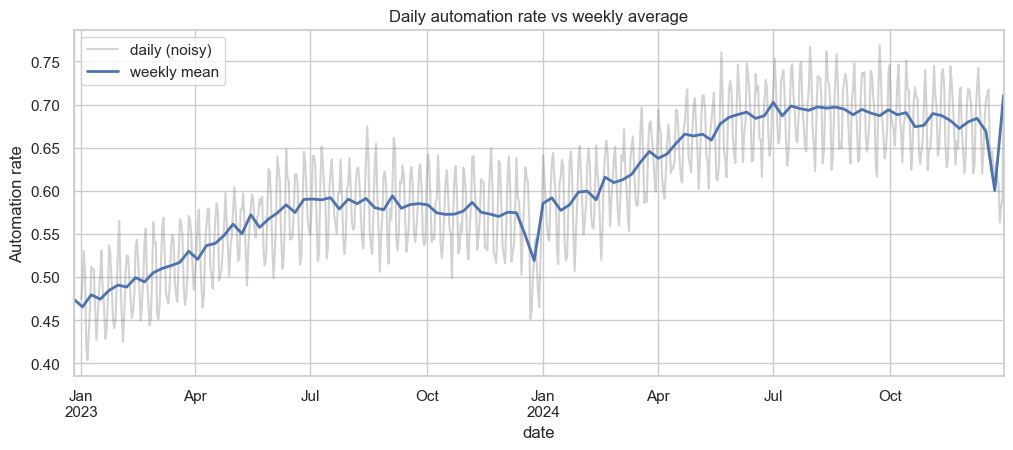

In [6]:
# Visualise: daily raw vs weekly smoothed
ax = df["auto_rate"].plot(alpha=0.35, color="#7F7F7F", label="daily (noisy)", figsize=(12, 4.5))
weekly["auto_rate"].plot(ax=ax, lw=2, color="#4C72B0", label="weekly mean")
ax.set(title="Daily automation rate vs weekly average", ylabel="Automation rate")
ax.legend();


> 🎯 **Resampling is your first weapon against noise.** Daily data is jittery; weekly or monthly aggregates expose the underlying signal. The right granularity depends on the question — daily for operations, weekly for trends, monthly for strategy.

## 5. Rolling windows — smoothing without losing rows

Resampling smoothed the noise but *cost us rows* — 730 days became 106 weeks, and for daily operations you still want a value every day. Rolling windows give you the best of both: smooth the noise yet keep one row per day. Resampling collapses many rows into one. **Rolling windows** keep every row but replace each value with an aggregate of the surrounding rows.

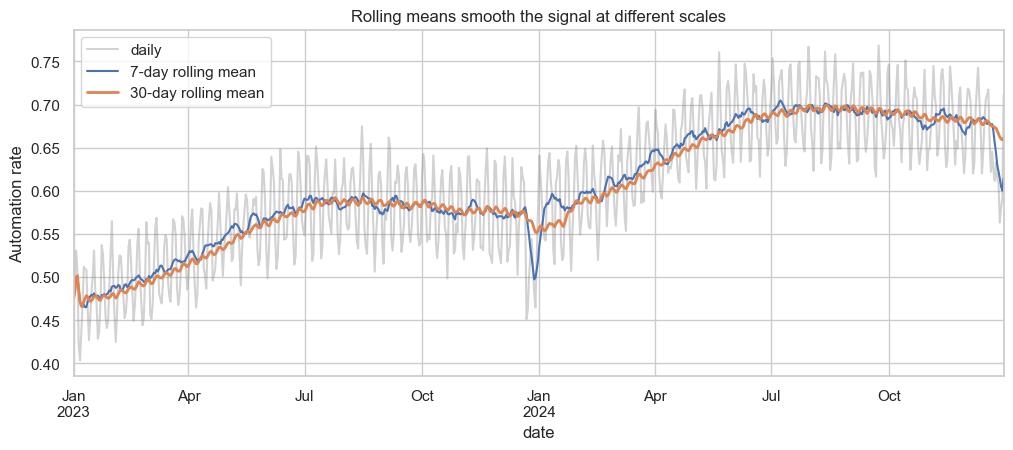

In [7]:
# 7-day and 30-day rolling means
df["roll_7"]  = df["auto_rate"].rolling(window=7,  min_periods=1).mean()
df["roll_30"] = df["auto_rate"].rolling(window=30, min_periods=1).mean()

ax = df["auto_rate"].plot(alpha=0.35, color="grey", label="daily", figsize=(12, 4.5))
df["roll_7"].plot(ax=ax, label="7-day rolling mean")
df["roll_30"].plot(ax=ax, lw=2, label="30-day rolling mean")
ax.set(title="Rolling means smooth the signal at different scales", ylabel="Automation rate")
ax.legend();

**Rolling vs resampling — the difference:**

- *Resampling* changes the time grid (one row per week instead of one per day).
- *Rolling* preserves the grid but each value is now a window aggregate.

> 💡 **`min_periods`** controls what happens at the edges. `min_periods=1` lets the window shrink at the start (so the first 6 days don't become `NaN`). Drop it for stricter behaviour.

---

### ✋ Quick exercise (~2 min) — A fortnightly smoother

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The support team likes the 7- and 30-day views, but wants a **14-day** (fortnightly) rolling mean too. Add a `roll_14` column to `df` and print its value on the most recent day.


In [8]:
# ✍️ Your turn 👇
df["roll_14"] = ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
df["roll_14"] = df["auto_rate"].rolling(window=14, min_periods=1).mean()
print(round(df["roll_14"].iloc[-1], 3))
```

Same `.rolling(...).mean()` recipe as the 7- and 30-day windows — just a different `window`. `min_periods=1` keeps early rows instead of dropping them.
</details>


## 6. Date arithmetic — `.shift` and `.diff`

Smoothing showed us the *level* of the series; forecasting cares just as much about *change* — "how much did it move vs yesterday? vs the same day last week?" Answering that means comparing each value to an earlier one, which is exactly what shift and diff do. Two operations that show up constantly:

- `s.shift(k)` — slide the series down by `k` rows (lag/lead).
- `s.diff(k)` — `s - s.shift(k)`. The change from `k` periods ago.

            auto_rate  delta_1d  delta_7d
date                                     
2024-12-21      0.646     0.024     0.000
2024-12-22      0.623    -0.022    -0.058
2024-12-23      0.612    -0.012    -0.094
2024-12-24      0.633     0.022    -0.077
2024-12-25      0.615    -0.018    -0.102
2024-12-26      0.608    -0.007    -0.051
2024-12-27      0.563    -0.044    -0.059
2024-12-28      0.581     0.017    -0.065
2024-12-29      0.591     0.011    -0.032
2024-12-30      0.711     0.120     0.099


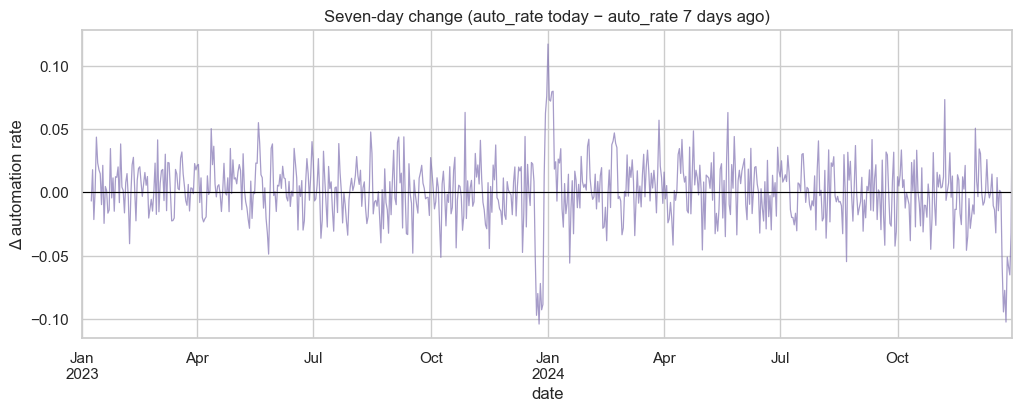

In [9]:
# Day-over-day change
df["delta_1d"] = df["auto_rate"].diff(1)

# 7-day momentum (today vs the same day last week)
df["delta_7d"] = df["auto_rate"].diff(7)

print(df[["auto_rate", "delta_1d", "delta_7d"]].tail(10).round(3))

# Plot the 7-day delta — exposes the weekly seasonality
ax = df["delta_7d"].plot(lw=0.9, color="#8172B2", alpha=0.7, figsize=(12, 4))
ax.axhline(0, color="black", lw=0.8)
ax.set(title="Seven-day change (auto_rate today − auto_rate 7 days ago)",
       ylabel="Δ automation rate");


> 🎯 **Why differencing matters.** A noisy trending series often has a *much* more stable difference. For forecasting, this is critical — most classical models assume the series is "stationary" (constant mean, constant variance), and `.diff()` is your first stationarity tool.

### 🔮 Predict the output

`.shift(1)` slides a series down by one row. What lands in the **first** position, and what does that do to a downstream `.sum()`?

```python
import pandas as pd

s = pd.Series([10, 12, 11, 15])
lag = s.shift(1)
print(lag.tolist())
print(lag.sum())
```

Predict both lines **before** running. What is the first element of `lag`?

In [10]:
import pandas as pd

s = pd.Series([10, 12, 11, 15])
lag = s.shift(1)
print("lagged :", lag.tolist())
print("sum    :", lag.sum())

lagged : [nan, 10.0, 12.0, 11.0]
sum    : 33.0


<details>
<summary>💡 <b>Answer</b></summary>

**`lag` is `[nan, 10.0, 12.0, 11.0]`; `sum` is `33.0`.** Shifting down by 1 has **nothing** to put in the first slot, so pandas fills it with `NaN` (and the whole series becomes `float`). The `NaN` is then *skipped* by `.sum()`, so you get `10 + 12 + 11 = 33`, computed over only three values. This is why lag/diff features always start with missing rows — you must `.dropna()` (or align the index) before feeding them to a model, or the first prediction is built on a gap.
</details>

## 7. Decomposition — trend + seasonality + residual

Here's the payoff of mental model #1. We *built* the series in §2 from trend + seasonality + noise; now we run that in reverse and recover each piece. Any time series can be (approximately) split into three pieces:

```
observed = trend + seasonality + residual
```

`statsmodels` does this in one call.

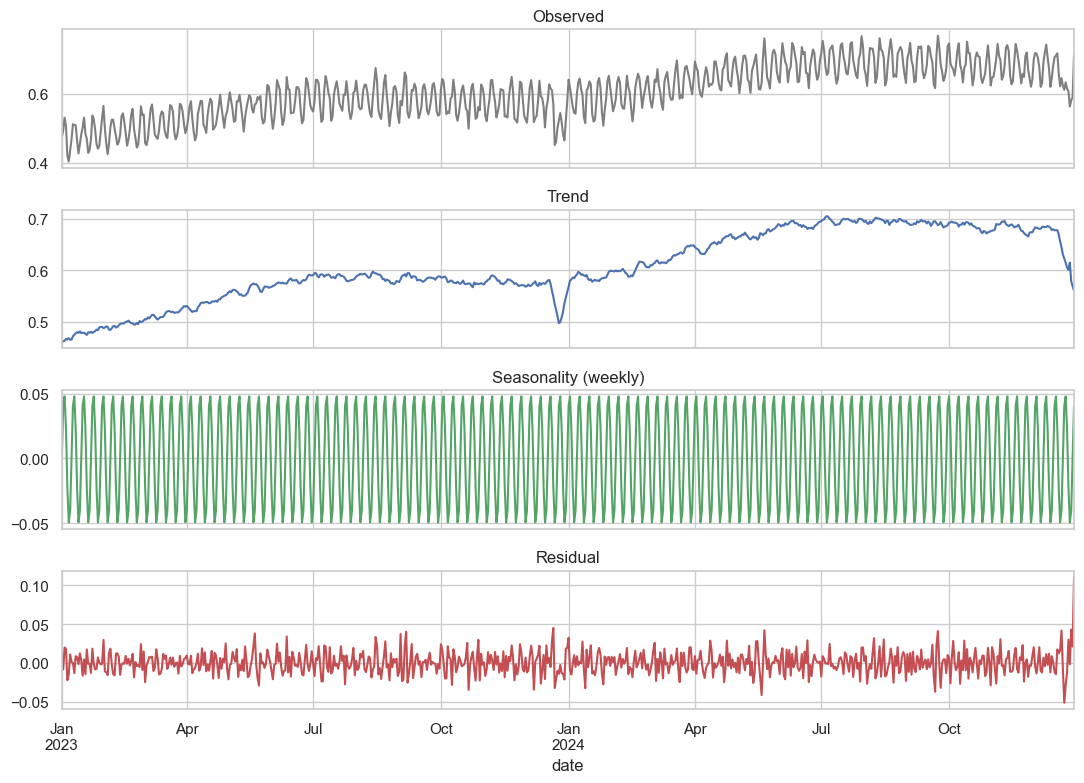

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose with weekly seasonality (period = 7)
decomp = seasonal_decompose(df["auto_rate"], model="additive", period=7,
                             extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
df["auto_rate"].plot(ax=axes[0], color="#7F7F7F"); axes[0].set_title("Observed")
decomp.trend.plot(ax=axes[1], color="#4C72B0");    axes[1].set_title("Trend")
decomp.seasonal.plot(ax=axes[2], color="#55A467"); axes[2].set_title("Seasonality (weekly)")
decomp.resid.plot(ax=axes[3], color="#C44E52");    axes[3].set_title("Residual")
plt.tight_layout(); plt.show()


**Reading the four panels.**

- **Observed** — the raw series, jittery.
- **Trend** — the slow upward drift we baked into the data.
- **Seasonality** — the weekly cycle, repeated.
- **Residual** — everything else, ideally noise. If residuals show structure, your decomposition missed something (e.g., a second seasonality, an outlier, a regime change).

> 💡 **Decomposition before modelling.** A 5-minute decomposition plot tells you which patterns a model needs to capture — and which ones it can ignore. Worth the time on every new time series you meet.

---

### ✋ Quick exercise (~2 min) — How big is the weekly swing?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The `decomp` object isolated the weekly pattern in `decomp.seasonal`. Compute the **peak-to-trough size** of that weekly effect (its max minus its min) — i.e. how much the day-of-week alone moves the automation rate.


In [12]:
# ✍️ Your turn 👇
weekly_swing = ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
weekly_swing = decomp.seasonal.max() - decomp.seasonal.min()
print(round(weekly_swing, 3))
```

The seasonal component repeats every 7 days, so its range is the gap between the strongest and weakest weekday — the pure weekly effect after trend and noise are removed.
</details>


## 8. Forecasting — three baselines you must beat

We've tamed the noise and named the structure — now we finally *predict*. But mental model #2 sets the ground rules first (the deep-dive below is the most important idea in the notebook), and a hard truth comes with it: before any fancy model earns its keep, it has to beat the embarrassingly simple baselines. Before you reach for fancy models, you must beat the **trivial** baselines. Any model that doesn't beat a naive forecast isn't earning its complexity.

### 🔬 What actually happens when you split a time series?

The very next code cell does something that looks trivial but is the single most
important line in the whole notebook:

```python
train = df.iloc[:700]    # the EARLIER 700 days
test  = df.iloc[700:]    # the LATER 30 days
```

It splits **by time** — earlier rows train, later rows test. Coming from ordinary
tabular ML, your instinct is probably to *shuffle then split* (`train_test_split`).
For time series that instinct is **wrong**, and it produces a score that looks great
and means nothing. Here is the chain of reasoning, step by step.

**Step 1 — in forecasting, the test set is the FUTURE.** You are pretending it is
day 700 and asking *"what happens on days 701–730?"*. Those days haven't happened yet.

**Step 2 — a random shuffle scatters future days into the training set.** If you
shuffle all 730 days and take 80% for training, that training set contains day 728,
day 715, day 705 — days that are *after* many of your test days.

**Step 3 — the model now "sees the future".** A model that has trained on day 728
already knows roughly where the series ended up. Predicting day 705 is no longer
forecasting — it's interpolating between points it has memorised. This is called
**leakage**: information from the future has leaked into training.

**Step 4 — the score is falsely optimistic.** The model reports a tiny error on the
test set, you ship it, and in production — where the future genuinely isn't
available — it falls apart. You evaluated a fantasy.

> The fix is one line: **cut the timeline once.** Everything before the cut is the
> past you train on; everything after is the future you test on.


### The timeline — WRONG (random) vs RIGHT (chronological)

Picture the 730 days laid out left-to-right in time. Mark each as `T` (train) or `·` (test).

```text
                    past  ───────────────────────────────►  future
  WRONG  (shuffle then split — train & test interleaved in time):

   T T · T T T · T T · T T T T · T T · T T T · T  ← test days are
   └───────────────────────────────────────────┘    SCATTERED among
        train days surround test days on BOTH sides       train days
        → the model sees days AFTER the test day → LEAKAGE


  RIGHT  (chronological — one clean cut):

   T T T T T T T T T T T T T T T │ · · · · · · · · · ·
   └──────── train (past) ───────┤ └─── test (future) ───┘
                                 ▲
                          the split point
        every test day is AFTER every train day → no peeking
```

In the WRONG picture, to predict a `·` the model can lean on `T`s that come *later* in
time. In the RIGHT picture that's impossible — the test region is strictly to the right
of everything the model trained on, exactly like real life.


### WRONG vs RIGHT — the distinction at a glance

| | Random split (shuffle ➜ split) | Chronological split (`iloc[:k]` / `iloc[k:]`) |
|---|---|---|
| Test set represents | A random scatter of days | The **future** (a contiguous later block) |
| Order preserved? | No — destroyed by the shuffle | Yes — time order kept intact |
| Can the model see future points? | **Yes** — future days sit in training | No — training is strictly the past |
| Leakage? | **Yes** — future leaks into training | None |
| Reported error | Falsely **low** (too optimistic) | Honest — matches production |
| Right for | Ordinary i.i.d. tabular rows | **Any time series / forecasting task** |
| One-liner | `train_test_split(X, y, shuffle=True)` | `k = int(len(df)*0.8); df.iloc[:k], df.iloc[k:]` |

The mechanical difference is tiny; the consequence is enormous. The same model, same
data — only the split rule changes — gives you either a trustworthy number or a lie.


In [13]:
# 🔬 PROOF — watch the future bleed into the training set under a random split.
# Small, seeded, offline synthetic series with a clear upward trend.
import numpy as np
import pandas as pd

rng_demo = np.random.default_rng(0)
days   = pd.date_range("2024-01-01", periods=20, freq="D")
trend  = np.linspace(0.0, 1.0, 20)              # clean upward trend 0 → 1
demo   = pd.Series(trend + rng_demo.normal(0, 0.02, 20), index=days, name="value")

split = int(len(demo) * 0.8)                     # 16 train / 4 test

**Build a right (chronological) and a wrong (shuffled) split**

In [14]:
# ── RIGHT: chronological — cut the timeline once ──
train_chrono = demo.iloc[:split]
test_chrono  = demo.iloc[split:]

# ── WRONG: shuffle the rows, THEN take the first 80% as "train" ──
shuffled    = demo.sample(frac=1.0, random_state=0)   # seeded shuffle
train_rand  = shuffled.iloc[:split]
test_rand   = shuffled.iloc[split:]

def date_span(s):
    return f"{s.index.min().date()} → {s.index.max().date()}"

**Report — show how the shuffle leaks future dates into training**

In [15]:
print("RIGHT — chronological split")
print(f"  train dates: {date_span(train_chrono)}   ({len(train_chrono)} days)")
print(f"  test  dates: {date_span(test_chrono)}   ({len(test_chrono)} days)")
print(f"  ✅ every test date is AFTER every train date "
      f"(train ends {train_chrono.index.max().date()}, "
      f"test starts {test_chrono.index.min().date()})")

print("\nWRONG — random shuffle then split")
print(f"  train dates: {date_span(train_rand)}   ({len(train_rand)} days)")
print(f"  test  dates: {date_span(test_rand)}   ({len(test_rand)} days)")

# How many TRAIN days fall AFTER the earliest TEST day? Those are leaked future.
earliest_test = test_rand.index.min()
leaked = train_rand.index[train_rand.index > earliest_test]
print(f"  ⚠️  {len(leaked)} train days are LATER than the earliest test day "
      f"({earliest_test.date()}):")
print("     ", [d.date().isoformat() for d in sorted(leaked)])
print("     → the model trains on the future, then is 'tested' on the past. Leakage.")

RIGHT — chronological split
  train dates: 2024-01-01 → 2024-01-16   (16 days)
  test  dates: 2024-01-17 → 2024-01-20   (4 days)
  ✅ every test date is AFTER every train date (train ends 2024-01-16, test starts 2024-01-17)

WRONG — random shuffle then split
  train dates: 2024-01-02 → 2024-01-20   (16 days)
  test  dates: 2024-01-01 → 2024-01-16   (4 days)
  ⚠️  16 train days are LATER than the earliest test day (2024-01-01):
      ['2024-01-02', '2024-01-03', '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-12', '2024-01-14', '2024-01-15', '2024-01-17', '2024-01-18', '2024-01-19', '2024-01-20']
     → the model trains on the future, then is 'tested' on the past. Leakage.


In [16]:
# 🔬 PROOF #2 — leakage makes the error look ARTIFICIALLY small.
# Fit the most trivial "model" possible BOTH ways: predict each test point as the
# value of its nearest-in-time training neighbour. With a random split, a near-future
# training day sits right next to each test day → tiny error. With a chronological
# split, the model must extrapolate past the trend → an honest, larger error.

def nearest_neighbour_mae(train_s, test_s):
    """For each test point, predict the train value closest in TIME, then score MAE."""
    train_ord = train_s.sort_index()
    t_times   = train_ord.index.values.astype("datetime64[ns]").astype("int64")
    errs = []
    for ts, y_true in test_s.items():
        target = np.int64(ts.value)
        j      = int(np.argmin(np.abs(t_times - target)))   # closest training day in time
        errs.append(abs(y_true - train_ord.iloc[j]))
    return float(np.mean(errs))

In [17]:
mae_random  = nearest_neighbour_mae(train_rand,   test_rand)    # leaky split
mae_chrono  = nearest_neighbour_mae(train_chrono, test_chrono)  # honest split

print(f"MAE with WRONG random split   : {mae_random:.4f}   ← looks great, it's a lie")
print(f"MAE with RIGHT chronological  : {mae_chrono:.4f}   ← honest (must extrapolate)")
print(f"\nThe random split looks ~{mae_chrono / mae_random:.1f}x 'better' — "
      "purely because the future leaked in.")
print("In production the future is NOT available, so only the chronological number is real.")


MAE with WRONG random split   : 0.0394   ← looks great, it's a lie
MAE with RIGHT chronological  : 0.1492   ← honest (must extrapolate)

The random split looks ~3.8x 'better' — purely because the future leaked in.
In production the future is NOT available, so only the chronological number is real.


### 🧠 Mental model, and two cousins of this rule

> **🧠 In forecasting, the test set is the FUTURE — and you can't train on the future.**
> So you never shuffle. You cut the timeline once: the past trains, the future tests.
> If a number looks too good, suspect leakage before you celebrate.

Two closely related ideas follow from the same principle:

- **🎯 No peeking — never use future values as features.** Leakage isn't only about the
  split. A feature like "this month's total" or "a centred rolling mean" secretly
  contains information from *after* the point you're predicting. When engineering
  features for row *t*, only use data available *at or before* time *t* (lags, *trailing*
  rolling windows, `.shift(+k)` — never `.shift(-k)`).

- **🔁 Walk-forward / expanding-window validation is the time-series version of
  cross-validation.** Ordinary k-fold CV shuffles rows into random folds — which, as
  we just saw, leaks. The honest analogue grows the training window forward in time and
  always tests on the *next* block:

  ```text
  fold 1:  [train....]              | test |
  fold 2:  [train........]          | test |
  fold 3:  [train............]      | test |
  fold 4:  [train................]  | test |
            ── window expands → ──    always the FUTURE
  ```

  That is exactly the **walk-forward backtest** you'll build in §11 — the same
  "train on the past, test on the future" rule, applied repeatedly so your error
  estimate doesn't hinge on one lucky split.

> ⚠️ **Pitfall.** scikit-learn's default `train_test_split` shuffles (`shuffle=True`).
> Reaching for it on a time series is the #1 way beginners get a beautiful score that
> evaporates in production. For temporal data use `iloc[:k] / iloc[k:]` (as below) or
> `sklearn.model_selection.TimeSeriesSplit`, which never shuffles.


In [18]:
# Use the FIRST 700 days for training, hold out the LAST 30 for testing
train = df.iloc[:700]["auto_rate"]
test  = df.iloc[700:]["auto_rate"]
h     = len(test)         # horizon = 30 days
print(f"Train: {len(train)} days   Test: {h} days")


Train: 700 days   Test: 30 days


### Baseline 1 — *Naive*: tomorrow looks like today

In [19]:
# Repeat the last observed value for the whole horizon
last_value   = train.iloc[-1]
fc_naive     = pd.Series(last_value, index=test.index, name="naive")
print(f"Naive forecast: constant {last_value:.3f} for {h} days")


Naive forecast: constant 0.641 for 30 days


### Baseline 2 — *Seasonal naive*: this day-of-week looks like last week's

In [20]:
# Seasonal-naive: each day looks like the same weekday one week earlier.
# Tile the last 7 training values across the whole forecast horizon.
last_week = train.iloc[-7:].values
fc_snaive = pd.Series([last_week[i % 7] for i in range(len(test))],
                      index=test.index, name="snaive")

# Quick sanity check
print(fc_snaive.head(10).round(3))

date
2024-12-01    0.649
2024-12-02    0.709
2024-12-03    0.720
2024-12-04    0.670
2024-12-05    0.647
2024-12-06    0.620
2024-12-07    0.641
2024-12-08    0.649
2024-12-09    0.709
2024-12-10    0.720
Name: snaive, dtype: float64


### Baseline 3 — *Moving average*: this week's average extended

In [21]:
# Last 30-day mean carried forward
fc_ma = pd.Series(train.tail(30).mean(), index=test.index, name="ma30")
print(f"30-day moving-average forecast: {fc_ma.iloc[0]:.3f}")


30-day moving-average forecast: 0.679


### Holt-Winters — a proper baseline that handles trend + seasonality

In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Additive trend + weekly seasonal
model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7,
                              initialization_method="estimated")
fit   = model.fit()
fc_hw = fit.forecast(h)
fc_hw.name = "holt_winters"

# Inspect the fitted smoothing parameters
print(f"alpha (level)   = {fit.params['smoothing_level']:.3f}")
print(f"beta  (trend)   = {fit.params['smoothing_trend']:.3f}")
print(f"gamma (season)  = {fit.params['smoothing_seasonal']:.3f}")


alpha (level)   = 0.236
beta  (trend)   = 0.000
gamma (season)  = 0.000


/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


---

### ✋ Quick exercise (~2 min) — A faster moving-average baseline

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The `fc_ma` baseline carried the **last 30-day** mean forward. Build a snappier `fc_ma7` that carries the **last 7-day** mean over the test horizon instead, and print its (constant) value.


In [23]:
# ✍️ Your turn 👇
fc_ma7 = ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
fc_ma7 = pd.Series(train.tail(7).mean(), index=test.index, name="ma7")
print(round(fc_ma7.iloc[0], 3))
```

Exactly the 30-day MA recipe with a shorter window: a 7-day average reacts faster to the most recent level but is noisier.
</details>


## 9. Visualising the forecasts

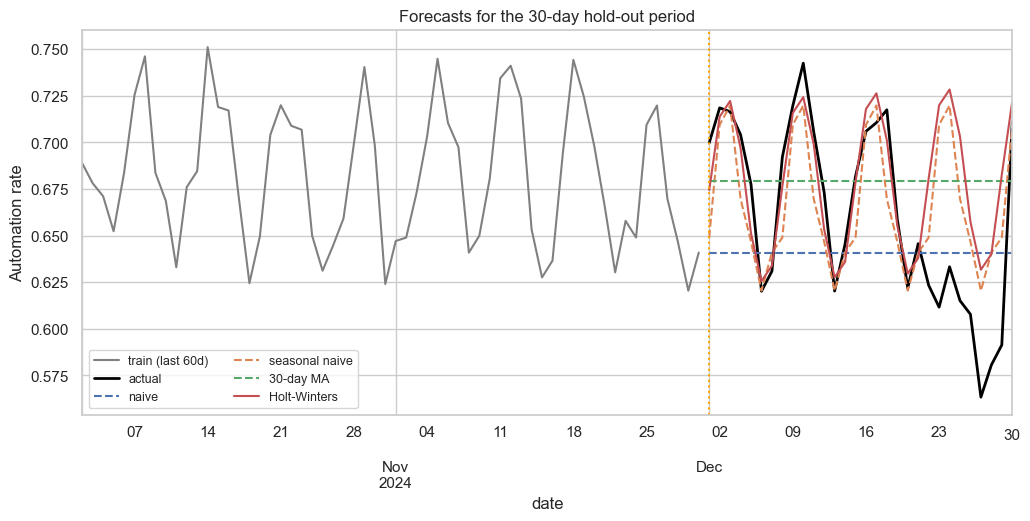

In [24]:
ax = train.tail(60).plot(color="grey", label="train (last 60d)", figsize=(12, 5))
test.plot(ax=ax, color="black", lw=2, label="actual")
pd.DataFrame({"naive": fc_naive, "seasonal naive": fc_snaive,
              "30-day MA": fc_ma, "Holt-Winters": fc_hw}).plot(ax=ax, style=["--", "--", "--", "-"])
ax.axvline(test.index[0], color="orange", ls=":")
ax.set(title="Forecasts for the 30-day hold-out period", ylabel="Automation rate")
ax.legend(ncol=2, fontsize=9);

## 10. Evaluating forecasts — MAE, RMSE, MAPE

We have four forecasts on the chart, all plausible-looking. Eyeballing can't pick a winner — "looks close" isn't a number you can defend in a review. We need an error metric. Three cover most cases:

- **MAE** (mean absolute error) — in target units. Easy to communicate.
- **RMSE** (root mean squared error) — like MAE but penalises big errors.
- **MAPE** (mean absolute percentage error) — unit-free; compares across series of different scales.

In [25]:
def evaluate(y_true, y_pred, name):
    mae  = (y_true - y_pred).abs().mean()
    rmse = ((y_true - y_pred) ** 2).mean() ** 0.5
    mape = ((y_true - y_pred).abs() / y_true.abs()).mean() * 100
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE %": mape}


rows = []
for fc, name in [(fc_naive, "naive"), (fc_snaive, "seasonal naive"),
                 (fc_ma, "30-day MA"), (fc_hw, "Holt-Winters")]:
    rows.append(evaluate(test, fc, name))

results = pd.DataFrame(rows).set_index("model").round(4)
print(results.sort_values("MAE"))


                   MAE    RMSE  MAPE %
model                                 
Holt-Winters    0.0284  0.0426  4.5507
seasonal naive  0.0291  0.0389  4.5389
30-day MA       0.0441  0.0517  6.9344
naive           0.0454  0.0527  6.7407


**How to read this table.**

- The model with the **lowest MAE / RMSE** is winning *on this hold-out*.
- A single hold-out is one data point. For trust, do **walk-forward backtesting** (next section).
- MAPE in single digits is good for most business forecasts. Above 20% the forecast is little better than a hand-wave.

> 🎯 **The "you must beat" line.** If your shiny new model can't beat *seasonal naive*, the model is not the problem — your data has very little structure to learn, or your features are weak. Walk away with the simple model.

> 🚫 **Misconception — "MAPE treats over- and under-forecasting the same."**
> MAPE divides the error by the **actual** value, so it is *asymmetric*: under-forecasting is capped at 100%, while over-forecasting is unbounded — and it **explodes (or divides by zero)** whenever the actual is near zero. It also can't be used on series that hit zero. For low or zero values, prefer **MAE/RMSE** or **sMAPE**.

---

### ✋ Quick exercise (~2 min) — Quantify the win

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Management wants one number: **how much lower is Holt-Winters' MAE than the naive baseline's**, in percent? Pull both values from the `results` table and compute the improvement.


In [26]:
# ✍️ Your turn 👇
improvement = ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
naive_mae = results.loc["naive", "MAE"]
hw_mae    = results.loc["Holt-Winters", "MAE"]
improvement = (1 - hw_mae / naive_mae) * 100
print(f"{improvement:.1f}% lower MAE")
```

`results` is just a DataFrame, so `.loc[row, col]` reads each MAE; `1 - hw/naive` turns the ratio into a percentage reduction in average error.
</details>


## 11. Walk-forward backtesting — the honest evaluation

A single train/test split can be lucky. Walk-forward refits the model on a growing window and forecasts a small step at a time, mimicking how the forecast would actually be used in production.

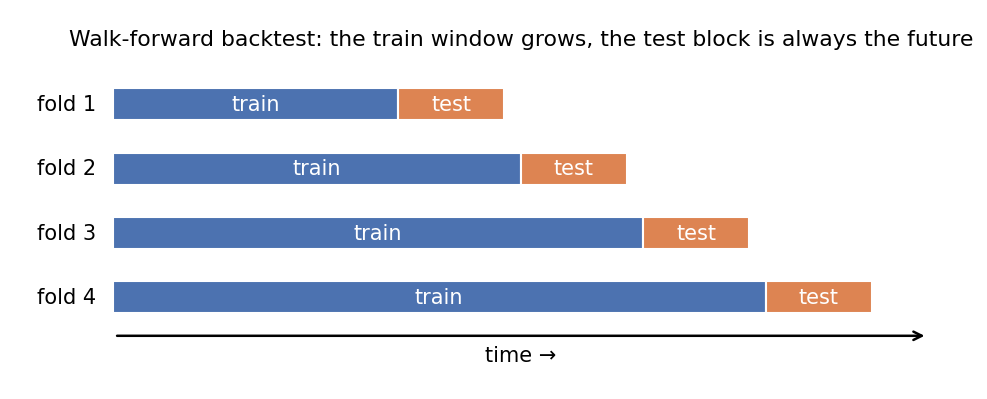


In [27]:
# Cheaper version: refit Holt-Winters every 60 days, forecast the next 30
def walk_forward(series, model_fn, horizon=30, step=30, min_train=180):
    """Refit at each step; forecast `horizon` ahead; return a DataFrame of errors."""
    errs = []
    for start in range(min_train, len(series) - horizon, step):
        train = series.iloc[:start]
        test  = series.iloc[start:start + horizon]
        try:
            preds = model_fn(train, horizon)
            errs.append({
                "anchor_date": series.index[start].date(),
                "MAE":  (test - preds).abs().mean(),
                "RMSE": ((test - preds) ** 2).mean() ** 0.5,
            })
        except Exception as e:
            print(f"  fold @ {series.index[start].date()}: {type(e).__name__}: {e}")
    return pd.DataFrame(errs)

**Define the Holt-Winters fitter and run the backtest**

In [28]:
def hw_forecast(train, h):
    m = ExponentialSmoothing(train, trend="add", seasonal="add",
                              seasonal_periods=7,
                              initialization_method="estimated")
    return m.fit().forecast(h)


bt = walk_forward(df["auto_rate"], hw_forecast, horizon=30, step=60, min_train=200)
print(bt.round(4))
print(f"\nHolt-Winters — average over {len(bt)} folds: "
      f"MAE = {bt['MAE'].mean():.4f}, RMSE = {bt['RMSE'].mean():.4f}")

/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/

  anchor_date     MAE    RMSE
0  2023-07-20  0.0226  0.0260
1  2023-09-18  0.0084  0.0115
2  2023-11-17  0.0135  0.0159
3  2024-01-16  0.0111  0.0136
4  2024-03-16  0.0155  0.0202
5  2024-05-15  0.0252  0.0290
6  2024-07-14  0.0131  0.0155
7  2024-09-12  0.0185  0.0223
8  2024-11-11  0.0163  0.0199

Holt-Winters — average over 9 folds: MAE = 0.0160, RMSE = 0.0193


/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


> 📈 **One number, many folds.** The average hides the spread — this chart shows the error for each refit so you can see how *stable* Holt-Winters really is.

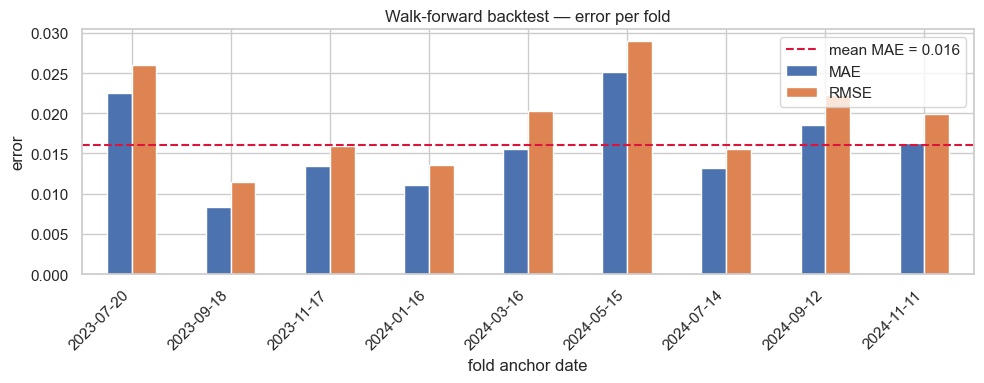

In [29]:
# Plot the error of every fold so the spread behind the average is visible
ax = bt.plot(x="anchor_date", y=["MAE", "RMSE"], kind="bar", figsize=(10, 4))
ax.axhline(bt["MAE"].mean(), color="crimson", ls="--", lw=1.5,
           label=f"mean MAE = {bt['MAE'].mean():.3f}")
ax.set(title="Walk-forward backtest — error per fold",
       xlabel="fold anchor date", ylabel="error")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

You now have a number that *generalises* — the average error across many different hold-out windows. That's the honest answer to "how well will this forecast do on next month?", not "how well did it do on the one hold-out I happened to pick".

## 12. The full forecast — 90 days ahead

This is the deliverable the whole notebook promised. Backtesting (§11) earned our trust in Holt-Winters, so now we do the real thing: refit on **all** the data and forecast the next 90 days of automation rate — the number the business actually asked for.

/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


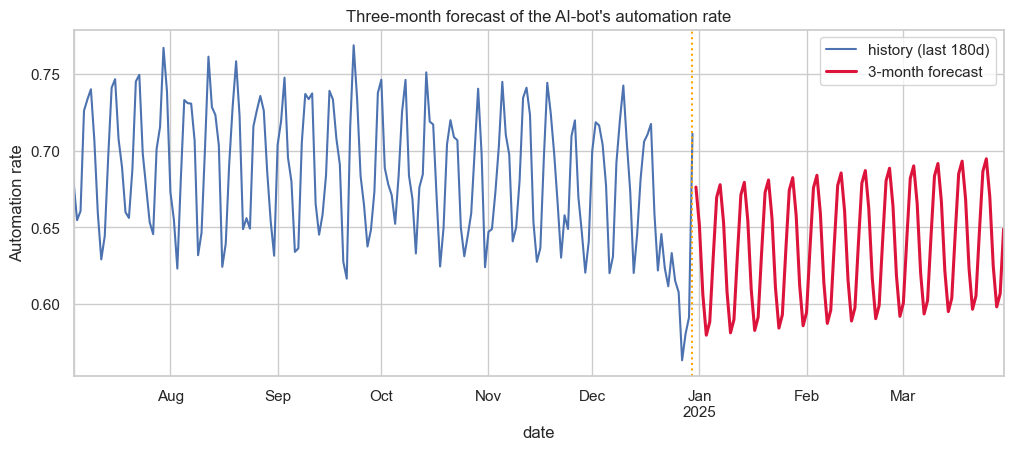

Last observed value : 0.711
Forecast for day +30: 0.658
Forecast for day +90: 0.649


In [30]:
# Refit on ALL the data and forecast the next 90 days
final_model = ExponentialSmoothing(df["auto_rate"], trend="add",
                                   seasonal="add", seasonal_periods=7,
                                   initialization_method="estimated").fit()
future_idx = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=90, freq="D")
forecast   = pd.Series(final_model.forecast(90).values, index=future_idx)

ax = df["auto_rate"].iloc[-180:].plot(label="history (last 180d)", figsize=(12, 4.5))
forecast.plot(ax=ax, color="crimson", lw=2.2, label="3-month forecast")
ax.axvline(df.index[-1], color="orange", ls=":")
ax.set(title="Three-month forecast of the AI-bot's automation rate", ylabel="Automation rate")
ax.legend()
plt.show()

print(f"Last observed value : {df['auto_rate'].iloc[-1]:.3f}")
print(f"Forecast for day +30: {forecast.iloc[29]:.3f}")
print(f"Forecast for day +90: {forecast.iloc[89]:.3f}")

## 13. The forecasting ecosystem — the same task in several top libraries

Holt-Winters gave us a solid baseline with **statsmodels**. But "fit one model from one library" is not how forecasting is done at scale. Production teams reach for libraries that bundle **dozens of models**, **time-aware cross-validation**, and **prediction intervals** behind *one* API — so you can try ten models in the time it took to hand-write one.

Here's the landscape, mapped to the job you're doing:

| Library | `pip install` | Best at | Go deeper |
|---|---|---|---|
| **statsmodels** | `statsmodels` | The classics done right: ARIMA/SARIMAX, ETS, Theta, decomposition, diagnostics | A1 |
| **StatsForecast** (Nixtla) | `statsforecast` | *Blazing-fast* classical models (AutoARIMA/AutoETS) across thousands of series in parallel | A2 |
| **sktime** | `sktime` | scikit-learn API for time series: pipelines, reductions, time-aware CV | A2 |
| **Darts** | `darts` | One `TimeSeries` type; every model from ARIMA to N-HiTS to Transformer | A2 |
| **Prophet / NeuralProphet** | `prophet` | Decomposable, stakeholder-friendly, holidays built in | A2 |
| **MLForecast / NeuralForecast** (Nixtla) | `mlforecast` / `neuralforecast` | Gradient-boosting & deep-learning forecasting at scale | A2 / A3 |
| **TimesFM / Chronos / TabPFN-TS** | see A4 | Zero-shot **foundation** forecasters — *no training* | A4 |

The rest of this section runs the **same `train` / `test` split** through several of these. Everything installed runs for real; anything that isn't prints its reference API and is skipped — so the notebook stays 100% offline-runnable.

### 🔬 What actually happens — every forecaster wears the same contract

It's easy to be intimidated by a shelf of forecasting libraries. Don't be: underneath, they all implement the **same two-verb contract** you already used with Holt-Winters.

```text
   history ──▶  model.fit( past )  ──▶  model.predict( h )  ──▶  ŷ for the next h steps
                └───────────────── statsmodels · sktime · Darts · StatsForecast · Prophet ─────────────────┘
```

What actually differs between them is **not** the core verb — it's the *batteries*:

- **How many models** sit behind that contract (statsmodels: a curated classical set · Darts: everything incl. deep nets).
- **How they cross-validate** in a way that respects time (sktime's `ExpandingWindowSplitter`, Nixtla's `cross_validation`).
- **Whether intervals come for free** (Nixtla's `level=[90]`, Darts' `num_samples`, Prophet's `yhat_lower/upper`).
- **How they scale** (StatsForecast vectorises one model over *thousands* of series; statsmodels fits one at a time).

So learning a new forecasting library is mostly learning *its data container and its CV helper* — the `fit`/`predict` you already know.

In [31]:
# A real tour through statsmodels' classical forecasters — same train/test, one comparison table.
# (statsmodels is a core dependency, so every model below runs offline, for real.)
import warnings
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

def _series(values):                       # align any forecaster's output to the test index
    return pd.Series(np.asarray(values), index=test.index)

In [32]:
eco_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")        # silence convergence chatter for a clean table
    fc_theta = _series(ThetaModel(train, period=7).fit().forecast(h).values)
    eco_rows.append(evaluate(test, fc_theta, "Theta (statsmodels)"))

    fc_ar = _series(AutoReg(train, lags=14, old_names=False).fit().forecast(steps=h).values)
    eco_rows.append(evaluate(test, fc_ar, "AutoReg(14) (statsmodels)"))

    fc_sx = _series(SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)
                            ).fit(disp=False).forecast(h).values)
    eco_rows.append(evaluate(test, fc_sx, "SARIMAX (statsmodels)"))

    fc_ets = _series(ETSModel(train, error="add", trend="add", seasonal="add",
                              seasonal_periods=7).fit(disp=False).forecast(h).values)
    eco_rows.append(evaluate(test, fc_ets, "ETS (statsmodels)"))

# Compare like-for-like against §10's baselines + Holt-Winters (the `rows` list from §10).
eco = pd.DataFrame(eco_rows + rows).set_index("model").round(4).sort_values("MAE")
print(eco)

                              MAE    RMSE  MAPE %
model                                            
SARIMAX (statsmodels)      0.0270  0.0398  4.3096
Theta (statsmodels)        0.0279  0.0426  4.4576
AutoReg(14) (statsmodels)  0.0279  0.0398  4.4502
ETS (statsmodels)          0.0284  0.0426  4.5504
Holt-Winters               0.0284  0.0426  4.5507
seasonal naive             0.0291  0.0389  4.5389
30-day MA                  0.0441  0.0517  6.9344
naive                      0.0454  0.0527  6.7407


**Read the table the same way you read §10.** A handful of "proper" models now sit beside the baselines — and the lesson from §8 still holds: *the seasonal-naive baseline is the bar to beat*, and several of these classical models clear it only modestly on this clean synthetic series. On messy real data the gap widens, and the value of being able to **try ten models in ten lines** is exactly what the libraries below buy you.

> 🏆 **The whole leaderboard in one glance.** Same numbers as the table above, sorted so the smallest (best) MAE sits on top.

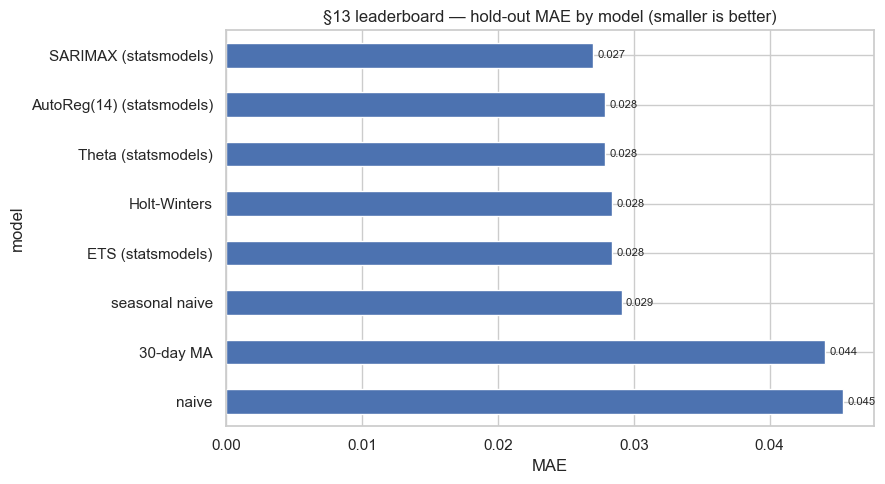

In [33]:
# Turn the leaderboard table into a bar chart — smallest (best) MAE on top
ax = eco["MAE"].sort_values(ascending=False).plot.barh(color="#4C72B0", figsize=(9, 5))
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=8)
ax.set(title="§13 leaderboard — hold-out MAE by model (smaller is better)", xlabel="MAE")
plt.tight_layout(); plt.show()

In [34]:
# StatsForecast (Nixtla): the SAME classical models, but vectorised to run across MANY series fast.
# Its one quirk is the input shape — "long" format with columns: unique_id, ds, y.
sf_train = train.reset_index()
sf_train.columns = ["ds", "y"]
sf_train.insert(0, "unique_id", "auto_rate")
print("StatsForecast expects this long format:\n", sf_train.head(3).to_string(index=False), "\n")

StatsForecast expects this long format:
 unique_id         ds        y
auto_rate 2023-01-01 0.474646
auto_rate 2023-01-02 0.493908
auto_rate 2023-01-03 0.530769 



In [35]:
try:
    from statsforecast import StatsForecast
    from statsforecast.models import AutoETS, AutoARIMA, SeasonalNaive
    sf = StatsForecast(
        models=[AutoETS(season_length=7), AutoARIMA(season_length=7), SeasonalNaive(season_length=7)],
        freq="D", n_jobs=1,
    )
    sf.fit(sf_train)
    sf_fc = sf.predict(h=h, level=[90])          # point forecast + a 90% interval, for free
    fc_sf = pd.Series(sf_fc["AutoETS"].values, index=test.index)
    print("StatsForecast AutoETS  MAE:", round((test - fc_sf).abs().mean(), 4))
    print("interval columns returned:", [c for c in sf_fc.columns if "lo" in c or "hi" in c])
except ImportError:
    print("statsforecast not installed — `pip install statsforecast` to run this for real.")
    print("Reference API:")
    print("  sf = StatsForecast(models=[AutoETS(season_length=7), AutoARIMA(season_length=7)], freq='D')")
    print("  sf.fit(long_df);  sf.predict(h=30, level=[90])   # → point + AutoETS-lo-90 / AutoETS-hi-90")
    print("  sf.cross_validation(df=long_df, h=30, n_windows=5)   # walk-forward, built in")

statsforecast not installed — `pip install statsforecast` to run this for real.
Reference API:
  sf = StatsForecast(models=[AutoETS(season_length=7), AutoARIMA(season_length=7)], freq='D')
  sf.fit(long_df);  sf.predict(h=30, level=[90])   # → point + AutoETS-lo-90 / AutoETS-hi-90
  sf.cross_validation(df=long_df, h=30, n_windows=5)   # walk-forward, built in


### sktime & Darts — the same task, two more APIs

You'll meet these in depth in **appendix A2**; here's the shape so you recognise it.

```python
# ── sktime — scikit-learn for time series (uncomment after `pip install sktime`) ──
# from sktime.forecasting.ets import AutoETS
# from sktime.forecasting.base import ForecastingHorizon
# fh = ForecastingHorizon(test.index, is_relative=False)
# fc = AutoETS(auto=True, sp=7).fit(train).predict(fh)          # fit/predict, exactly like sklearn
# # time-aware CV: from sktime.split import ExpandingWindowSplitter
```

```python
# ── Darts — one TimeSeries type, every model (uncomment after `pip install darts`) ──
# from darts import TimeSeries
# from darts.models import ExponentialSmoothing
# series = TimeSeries.from_series(df["auto_rate"])
# tr, te = series[:-30], series[-30:]
# m = ExponentialSmoothing(seasonal_periods=7); m.fit(tr)
# fc = m.predict(30, num_samples=500)        # num_samples → a probabilistic forecast with intervals
```

> 🎯 **How to choose, in one line each.** Reach for **statsmodels** when you want the classics + diagnostics; **StatsForecast** when you have *many* series or want speed; **sktime** when you want sklearn-style pipelines & CV; **Darts** when you want classical *and* deep models behind one type; **Prophet** when stakeholders want a decomposition story; **foundation models** (A4) when you want a forecast with *no* training at all.

> 💡 **Don't forget the interval.** Every library above can return more than a point forecast — `level=[90]` (StatsForecast), `num_samples=` (Darts), `yhat_lower/upper` (Prophet), `conf_int()` (statsmodels SARIMAX). Those native intervals assume the model is correct. For a **distribution-free coverage guarantee** that wraps *any* of these forecasters — and that keeps holding under drift — see the new appendix [`../05_machine_learning/A5_conformal_prediction.ipynb`](../05_machine_learning/A5_conformal_prediction.ipynb) (§5 covers conformal prediction for time series). A point forecast tells the business *what*; the interval tells it *how much to trust it* — and that's usually what the decision actually hinges on.

## 🧪 Practice exercises

### Exercise 1 — ⭐ Monthly view

Resample the daily series to **monthly mean** and plot it. Then print the three highest-automation months across all 24 months.

In [36]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
monthly = df["auto_rate"].resample("ME").mean()

monthly.plot(marker="o", lw=2, figsize=(11, 4),
             title="Monthly average automation rate", ylabel="Automation rate")

print("Top-3 months:")
print(monthly.sort_values(ascending=False).head(3).round(3))
```

The pattern `series.resample("ME").mean().sort_values(...)` is a one-liner for "rank periods by metric" — you'll use it for revenue, sign-ups, etc.
</details>

### Exercise 2 — ⭐⭐ 30-day rolling standard deviation

The **volatility** of a series is often as interesting as its level. Compute a 30-day rolling standard deviation of `auto_rate` and plot it. Where is the series most volatile?

In [37]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
vol = df["auto_rate"].rolling(30).std()

vol.plot(color="#DD8452", lw=1.6, figsize=(11, 4),
         title="30-day rolling standard deviation (volatility)", ylabel="Standard deviation")

print(f"Most volatile date: {vol.idxmax().date()}  (std = {vol.max():.3f})")
```

The dates of high volatility tend to align with the *Christmas dips* we baked in — a small shock in the series shows up as elevated rolling-std weeks later.
</details>

### Exercise 3 — ⭐⭐ Beat the naive baseline

Build an even simpler forecast: **predict tomorrow as the average of the last 14 days**, day-by-day for the test set. Compute its MAE on the 30-day hold-out and compare with the existing baselines.

In [38]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
# Predict each test day using the previous 14 days' mean, recursively
window = list(train.iloc[-14:])
preds  = []
for _ in range(h):
    preds.append(np.mean(window))
    window.pop(0); window.append(preds[-1])    # use our own prediction as the new "yesterday"

fc_ma14 = pd.Series(preds, index=test.index)
print(f"MA-14 recursive MAE: {(test - fc_ma14).abs().mean():.4f}")
```

This is a **recursive** forecast — the model's own predictions feed the next step. Here it edges out the flat baselines (MAE ≈ 0.042 vs ≈ 0.045 for naive) but still trails seasonal naive and Holt-Winters: the rolling mean quickly flattens toward a constant, so it can't reproduce the weekly cycle — and any early error is recycled into every later step. Direct multi-step forecasts that model the seasonality (like Holt-Winters) do better.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

The cell below tries to plot the daily series with weekday names on the x-axis, but the dates aren't being interpreted as dates. Find and fix the bug.

```python
bad = pd.DataFrame({"date": ["2024-01-01","2024-01-02","2024-01-03"],
                    "v":    [0.5, 0.6, 0.55]})
bad.set_index("date")["v"].plot()
```

In [39]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Your fixed version  👇


<details>
<summary>💡 <b>Solution</b></summary>

The strings look like dates to *us* but pandas treats them as plain strings until you convert them.

```python
bad = pd.DataFrame({"date": ["2024-01-01","2024-01-02","2024-01-03"],
                    "v":    [0.5, 0.6, 0.55]})
bad["date"] = pd.to_datetime(bad["date"])    # <-- the missing step
bad = bad.set_index("date")
bad["v"].plot(marker="o")
```

**Rule of thumb.** The first thing you do after `pd.read_csv` is `df["date"] = pd.to_datetime(df["date"])`. Without that step, every time-aware pandas operation either fails or — worse — silently does the wrong thing.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Anomaly detection on residuals

Decompose `df['auto_rate']` (you already did this in §7). Flag any *residual* values more than 3 standard deviations from zero as anomalies, and print their dates.


<details>
<summary>💡 <b>Solution</b></summary>

```python
resid = decomp.resid.dropna()
threshold = 3 * resid.std()
anomalies = resid[resid.abs() > threshold]
print(f"Flagged {len(anomalies)} anomalies (|resid| > {threshold:.3f}):")
print(anomalies.head(10).round(3))
```

**Why "anomaly on the residual" works.** The trend and seasonal
components explain the expected pattern; whatever the residual
catches is, by construction, *unexpected*. The Christmas dips
you baked in around day 357 of 2023/24 should show up clearly.

</details>

### Stretch exercise B — ⭐⭐⭐ Forecast and compare two horizons

Forecast 14 days and 90 days ahead from the same Holt-Winters fit. Plot both forecasts on the same chart alongside the last 60 days of history. Comment on why long-horizon forecasts have wider uncertainty in practice.


<details>
<summary>💡 <b>Solution</b></summary>

```python
m = ExponentialSmoothing(df["auto_rate"], trend="add", seasonal="add",
                          seasonal_periods=7, initialization_method="estimated").fit()
f14 = m.forecast(14)
f90 = m.forecast(90)

ax = df["auto_rate"].iloc[-60:].plot(color="#4C72B0", lw=1.6, label="last 60d", figsize=(12, 4.5))
f14.plot(ax=ax, color="#55A467", lw=2.5, label="14-day forecast")
f90.plot(ax=ax, color="#C44E52", lw=2.0, alpha=0.7, label="90-day forecast")
ax.set(title="Two forecast horizons", ylabel="auto_rate")
ax.legend();
```

**Why long-horizon uncertainty grows.** Errors compound at each
step — the model uses *its own predictions* as inputs to the
next step. By day 90 the prediction is built on 90 layers of
"approximately correct" inputs, so the forecast's standard deviation grows
roughly like $\sqrt{h}$. Always report a *prediction interval*, not just
a point forecast, for anything beyond a few days.

</details>

### Stretch exercise C — ⭐⭐⭐ Compute MAPE and sMAPE

Implement the two most common forecast-accuracy metrics:

- **MAPE** (mean absolute percentage error): `mean( |y − ŷ| / |y| )`
- **sMAPE** (symmetric MAPE): `mean( 2·|y − ŷ| / (|y| + |ŷ|) )`

Test on:
```python
y_true = np.array([100, 200, 300, 400])
y_pred = np.array([110, 190, 330, 380])
```

Round both to three decimals.

In [40]:
# Your code here  👇
import numpy as np
y_true = np.array([100, 200, 300, 400])
y_pred = np.array([110, 190, 330, 380])

def mape(y, yhat):
    ...
def smape(y, yhat):
    ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import numpy as np

def mape(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.abs(y - yhat) / np.abs(y)))

def smape(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(2 * np.abs(y - yhat) / (np.abs(y) + np.abs(yhat))))

y_true = np.array([100, 200, 300, 400])
y_pred = np.array([110, 190, 330, 380])
print(f"MAPE  = {mape(y_true, y_pred):.3f}")
print(f"sMAPE = {smape(y_true, y_pred):.3f}")
```

**Reasoning.** MAPE is intuitive ("10% error on average") but has two well-known flaws: (1) it blows up when any `y` is near zero, and (2) it is **asymmetric** — over-forecasting by 50% counts as 50%, but a 50%-error under-forecast can score as up to 100%. sMAPE fixes the asymmetry by dividing by the average of `|y|` and `|ŷ|`. Neither metric is perfect (sMAPE is still bounded by `[0, 2]` and rewards bias-toward-zero), which is why production forecasting teams usually report **MAE plus MAPE** — MAE is the unit-faithful error, MAPE is the scale-free one. Read the assumptions both make before quoting them in a deck.
</details>

### Stretch exercise D — ⭐⭐⭐ Walk-forward backtest

Implement a **walk-forward backtest** for a one-step-ahead naïve forecaster ("tomorrow = today") and report the average MAE over the test region.

Setup:
```python
rng = np.random.default_rng(0)
series = np.cumsum(rng.normal(0, 1, 100))    # random walk, length 100
train_end = 60                               # use 0..60 as training
```

Walk forward from index `train_end` to the end: at each step, predict the next observation as the current one, then **advance the training window by 1**.

In [41]:
# Your code here  👇
import numpy as np
rng = np.random.default_rng(0)
series = np.cumsum(rng.normal(0, 1, 100))
train_end = 60

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import numpy as np
rng = np.random.default_rng(0)
series = np.cumsum(rng.normal(0, 1, 100))
train_end = 60

errors = []
for t in range(train_end, len(series) - 1):
    y_pred = series[t]              # naïve: tomorrow == today
    y_true = series[t + 1]
    errors.append(abs(y_true - y_pred))

print(f"walk-forward MAE = {np.mean(errors):.3f}")
print(f"steps evaluated  = {len(errors)}")
```

**Reasoning.** Three reasons this evaluation pattern matters. (1) **No look-ahead bias** — at every step the model only sees the past. Classic train/test splits trained once on the first 80% don't model how the system would behave in production, where data keeps arriving. (2) **Honest baseline.** A 'random-walk naïve' forecaster is what you must beat on financial / noisy series — if a fancier model can't beat it on walk-forward MAE, the fancier model isn't actually learning anything. (3) For real models you'd refit (or warm-update) the model at every step inside the loop. The pattern stays the same — only the `y_pred` line changes.
</details>

## 🎁 Bonus mini-project — A weekly forecasting report

Write a function `weekly_forecast_report(daily_series, weeks=4)` that:

1. Resamples the daily series to weekly mean.
2. Fits a Holt-Winters model with weekly seasonality.
3. Forecasts `weeks` weeks ahead.
4. Returns a tidy DataFrame with columns `date`, `actual_or_forecast`, `kind` (history / forecast).
5. Plots the last 26 weeks of history and the forecast on one chart.

In [42]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
def weekly_forecast_report(daily_series, weeks=4):
    weekly = daily_series.resample("W").mean()

    model = ExponentialSmoothing(weekly, trend="add", seasonal=None,
                                  initialization_method="estimated").fit()
    fc = model.forecast(weeks)

    history = weekly.rename("actual_or_forecast").to_frame()
    history["kind"] = "history"
    forecast = fc.rename("actual_or_forecast").to_frame()
    forecast["kind"] = "forecast"
    report = pd.concat([history, forecast])
    report.index.name = "date"

    last_26 = weekly.tail(26)
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(last_26.index, last_26, color="#4C72B0", lw=2, label="history")
    ax.plot(fc.index,      fc,      color="#C44E52", lw=2, label=f"{weeks}-week forecast")
    ax.set_title(f"Weekly automation rate — {weeks}-week forecast")
    ax.set_ylabel("Automation rate")
    ax.legend()
    plt.tight_layout(); plt.show()

    return report


rep = weekly_forecast_report(df["auto_rate"], weeks=8)
print(rep.tail(10).round(3))
```

**What you built.** A function you can hand to a colleague: feed it any daily metric, get back a weekly forecast plus the chart. This is the smallest possible "production-shaped" forecasting tool — and it's 20 lines.
</details>

## 🧠 Key takeaways

> 🧠 **The thread, end to end.** One metric — the bot's automation rate — carried from raw daily noise to a trusted 90-day forecast: we **indexed it by time** (§1–3), **smoothed the noise** (resample §4, roll §5), measured **change** (§6), **decomposed** it back into the trend + seasonality + noise we'd baked in (§7), **forecast** it against baselines we had to beat (§8), and — the discipline that makes any of it real — **trained on the past, tested on the future** (§8 split, §11 walk-forward). Both mental models did the work: *a series is trend + seasonality + noise*, and *you never train on the future*.

1. **Set a `DatetimeIndex`** with `pd.to_datetime` + `set_index`. Everything else flows from there.
2. **Resample** (`.resample(rule).agg(...)`) to change granularity; **roll** (`.rolling(window)`) to smooth at fixed granularity.
3. **`.diff(k)`** and **`.shift(k)`** are your tools for change-over-time and lag features.
4. **Decompose** before modelling: trend + seasonality + residual exposes what your model needs to capture.
5. **Three baselines you must beat:** naive (last value), seasonal naive, moving average.
6. **Holt-Winters** handles trend + seasonality with three parameters — a great default.
7. **Walk-forward backtesting** is the honest evaluation. One hold-out is one lucky sample.
8. Forecasts are *probability distributions* hiding inside point estimates. Report confidence intervals when you can.

## ✅ Self-assessment

- [ ] Convert a date column to `datetime` and set it as the index
- [ ] Slice a DataFrame by a date string or date range
- [ ] Resample from daily to weekly with a custom aggregation
- [ ] Compute a 7-day and 30-day rolling mean
- [ ] Decompose a series into trend + seasonality + residual
- [ ] Build a naive, seasonal-naive, and Holt-Winters forecast on the same data
- [ ] Evaluate forecasts with MAE / RMSE / MAPE
- [ ] Run a walk-forward backtest

## 🚀 Next step

Continue with **Notebook 12 — APIs & HTTP** (`../03_real_world_io/12_apis_and_http.ipynb`), where you stop generating data inline and start pulling it from the outside world — live HTTP APIs, then SQL databases. The pandas skills from this module are exactly what you'll use to wrangle what comes back.

> 🔭 **Going further (optional).** For methods beyond Holt-Winters, this module ships four appendix notebooks: `A1_forecasting_classical` (ARIMA / SARIMA / ETS), `A2_forecasting_prophet_libraries`, `A3_forecasting_deep_learning`, and `A4_forecasting_foundation_models`.